# Corrected diffusion: validate first, then compare query selection

This notebook repairs the numerical sampling problem identified in notebook 13 and runs a **small, controlled noisy comparison**. All output is saved here; no other file is needed to read the results.

The corrected default also refreshes parameter radius conditional on direction, using the polar volume factor r^(d-1). This improves magnitude exploration without projecting onto a sphere or changing the target. Section 2 compares runs with and without this update. Reference checks have finite Monte Carlo error: passing a tolerance is not proof of exact sampling.

**Unchanged:** hard MIN expert, clean observed decisions Y (no observation noise), objective F(theta,s,x)=theta dot (s*x), full summed inverse loss, and bounded target pi(theta) proportional to exp(-20 L(theta)) on [-1,1]^d. The algorithm sees only public candidates, the public MIN solver and past (S,Y).

**Changed:** the default sampler is now Gaussian-augmented Gibbs with random-direction slice updates, not the unadjusted projected Euler method in specification v2. Draw u given z from N(z,tau I), then update the CURRENT z with slice transitions preserving pi(z) exp(-||z-u||²/(2tau)). Final nonlocalized slice updates preserve pi itself. These transitions have the intended invariant distribution; short trajectories are still approximate and correlated. They are NOT certified exact independent samples. Old notebooks 11–13 explicitly select the preserved legacy backend.

The reported estimate is now the **ensemble mean of 16 samples** (the original first-sample option remains available). Disagreement uses ALL samples; exact query-score ties are randomized. Uniform and disagreement policies have the SAME sampler, point estimator, budgets and seed scheme. This is a query-selection ablation, **not a rerun of Random + incenter**.

**Small study:** 3 scenarios, dimensions 2/2/4, T=12, seeds 0/1/2, Gaussian parameter-noise sigma=0.02 every round, 96 fixed fresh held-out queries per scenario. No early stopping. We show first and sustained hits of 5-degree angle error and 0.01 held-out regret, but three seeds are not enough for general superiority claims.

Training pools are deliberately imbalanced in two scenarios. Tests deliberately cover the informative region / coordinate pairs evenly; this evaluation weighting is disclosed rather than hidden. Candidate and test designs are fixed independently of theta*. Repeated training queries are allowed.

**Important limitation:** exp(-beta L) is a loss-based distribution, NOT the true likelihood for Gaussian parameter noise. Inconsistent responses can pull mass toward theta=0. Better sampling does not cure that modeling issue or identify scale from homogeneous decisions.

Background: [Neal: Slice Sampling](https://arxiv.org/abs/physics/0009028), [Lee, Shen & Tian: Restricted Gaussian Oracles](https://arxiv.org/abs/2010.03106). Our finite inner slice transitions use a Gibbs-within-MCMC construction; we do not claim their oracle complexity bounds apply to this implementation.

In [1]:
from pathlib import Path
import sys, time, json
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from invoptlab.active import (
    ActiveBenchmarkRunner, ActiveEvaluationConfig, AlgorithmObservation,
    FixedCardinalityDecisionSpace, GaussianGibbsSampler, GaussianSmoothedSampler,
    InverseLossTarget, NestedLangevinActiveAlgorithm, NestedLangevinConfig,
    PublicDecisionProblem, RegretStoppingConfig, build_query_sensitive_scenarios,
    evaluate_active_run,
)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .2})
OUTPUT = ROOT / "outputs" / "active" / "14_corrected_diffusion"
OUTPUT.mkdir(parents=True, exist_ok=True)
CFG = NestedLangevinConfig(
    sampler="gaussian_gibbs", beta=20., parameter_domain="box", bound=1.,
    theta_samples=16, point_estimate="mean", query_tie_breaking="random",
    tau_schedule=(.5, .1, .02), gibbs_sweeps=6, conditional_slice_steps=4,
    target_slice_steps=32, radial_refresh=True, record_chain_trace=False, workers=1,
)
display(pd.DataFrame([{
    "sampler": CFG.sampler, "beta": CFG.beta, "samples": CFG.theta_samples,
    "Gaussian sweeps per tau": CFG.gibbs_sweeps,
    "slice steps per conditional": CFG.conditional_slice_steps,
    "final target slice steps": CFG.target_slice_steps,
    "point estimate": CFG.point_estimate, "T": 12, "seeds": "0,1,2",
    "parameter sigma": .02, "observation noise": "none",
}]))
print("Legacy-only Euler step sizes/burn-in fields are ignored by gaussian_gibbs.")

,sampler,beta,samples,Gaussian sweeps per tau,slice steps per conditional,final target slice steps,point estimate,T,seeds,parameter sigma,observation noise
0,gaussian_gibbs,20.0,16,6,4,32,mean,12,"0,1,2",0.02,none


Legacy-only Euler step sizes/burn-in fields are ignored by gaussian_gibbs.


## 1. Reproduce the bias and validate its repair

A one-dimensional conditional with eight observations has L(z)=8 max(0,-z), u=-0.3 and tau=0.1. Numerical integration supplies the reference independently of the sampler. Both short-chain checks use 32 transitions, discard 16 and retain four states, across 64 independent seeds. The longer legacy run shows why merely adding steps was not sufficient. MCSE here is across independent chain means, not across correlated states within a chain.

,method,reference mean,sample mean,bias estimate,MCSE,seconds
0,Legacy 32,0.164143,0.403081,0.238938,0.018123,0.437489
1,Legacy 320,0.164143,0.379776,0.215633,0.016071,4.060961
2,Corrected slice 32,0.164143,0.149863,-0.014280,0.008129,1.802745


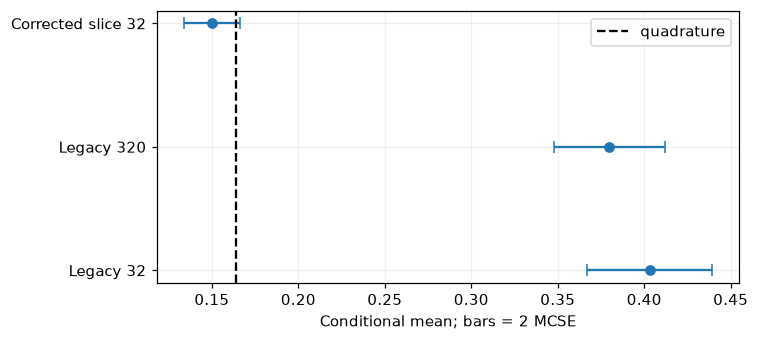

In [2]:
obs = [AlgorithmObservation(i+1, np.ones(1), np.zeros(1)) for i in range(8)]
forward = lambda theta, s: (theta*s < 0).astype(float)
density = lambda z: np.exp(-160*max(0., -z) - (z+.3)**2/.2)
normalizer = quad(density, -1, 1, points=[0], epsabs=1e-12)[0]
reference_mean = quad(lambda z: z*density(z), -1, 1, points=[0], epsabs=1e-12)[0] / normalizer
audit_rows, audit_means = [], {}
for method, steps in [("Legacy 32", 32), ("Legacy 320", 320), ("Corrected slice 32", 32)]:
    means = []
    begin = time.perf_counter()
    for seed in range(64):
        target = InverseLossTarget(1, 20., forward, obs)
        rng = np.random.default_rng(seed)
        if method.startswith("Legacy"):
            cfg = replace(CFG, sampler="projected_langevin", inner_steps=steps,
                          inner_burn_in=steps//2, inner_thinning=steps//8)
            value = GaussianSmoothedSampler(target, cfg, rng).run_inner_chain(
                np.array([-.3]), .1, .005).mean[0]
        else:
            sampler = GaussianGibbsSampler(target, CFG, rng)
            z, kept = np.array([-.3]), []
            for k in range(32):
                z = sampler.slice_step(z, u=np.array([-.3]), tau=.1)
                if k >= 16 and (k-16) % 4 == 0:
                    kept.append(z[0])
            value = np.mean(kept)
        means.append(value)
    audit_means[method] = np.array(means)
    audit_rows.append({
        "method": method, "reference mean": reference_mean, "sample mean": np.mean(means),
        "bias estimate": np.mean(means)-reference_mean,
        "MCSE": np.std(means, ddof=1)/8,
        "seconds": time.perf_counter()-begin,
    })
audit = pd.DataFrame(audit_rows)
display(audit.round(6))
assert abs(audit.iloc[-1]["bias estimate"]) < .035, "Conditional accuracy gate failed"
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.errorbar(audit["sample mean"], np.arange(3), xerr=2*audit["MCSE"], fmt="o", capsize=4)
ax.axvline(reference_mean, color="black", linestyle="--", label="quadrature")
ax.set(yticks=np.arange(3), yticklabels=audit["method"], xlabel="Conditional mean; bars = 2 MCSE")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Validate the complete sampler, not just its inner update

The coupled two-dimensional target below is integrated on midpoint grids independently of the implementation. We compare means, second moments and cross moment against independent endpoint trajectories. The larger-budget run is a sensitivity check, not automatic tuning. The grid itself is approximate; its refinement difference is reported. These checks validate specific small targets, not every future scenario.

Largest moment change when doubling grid resolution: 2.7344771575954496e-06


Without radius refresh seconds: 4.58


Default budget seconds: 5.53


Double mixing budget seconds: 10.74


,budget,moment,quadrature,estimate,error,MCSE
0,Without radius refresh,E theta1,0.51044,0.45700,-0.05344,0.02953
1,Without radius refresh,E theta2,0.51044,0.43368,-0.07676,0.02832
2,Without radius refresh,E theta1²,0.35785,0.31960,-0.03825,0.02639
3,Without radius refresh,E theta2²,0.35785,0.28992,-0.06793,0.02286
4,Without radius refresh,E theta1 theta2,0.34733,0.29414,-0.05319,0.02312
5,Default budget,E theta1,0.51044,0.45543,-0.05501,0.02623
6,Default budget,E theta2,0.51044,0.47944,-0.03100,0.02752
7,Default budget,E theta1²,0.35785,0.29481,-0.06304,0.02143
8,Default budget,E theta2²,0.35785,0.32601,-0.03183,0.02337
9,Default budget,E theta1 theta2,0.34733,0.29985,-0.04749,0.02143


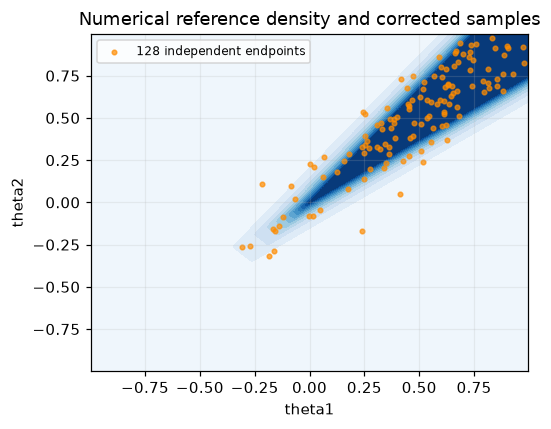

In [3]:
problem = PublicDecisionProblem(FixedCardinalityDecisionSpace(2, 1))
ref_queries = np.array([[.6, .8], [.8, .6]])
ref_decisions = np.eye(2)
ref_obs = [AlgorithmObservation(i+1, s, y) for i, (s, y) in enumerate(zip(ref_queries, ref_decisions))]
def reference_grid(n):
    axis = (np.arange(n)+.5)*2/n - 1
    points = np.stack(np.meshgrid(axis, axis), axis=-1).reshape(-1, 2)
    # Independent direct formula: min over the TWO feasible one-hot decisions.
    loss = sum((points*s*y).sum(axis=1) - (points*s).min(axis=1)
               for s, y in zip(ref_queries, ref_decisions))
    weights = np.exp(-20*loss); weights /= weights.sum()
    features = np.c_[points, points**2, points[:,0]*points[:,1]]
    return points, weights, weights @ features
ref_points, ref_weights, ref_moments = reference_grid(240)
_, _, fine_moments = reference_grid(480)
print("Largest moment change when doubling grid resolution:",
      float(np.max(np.abs(ref_moments-fine_moments))))
endpoint_rows, endpoint_draws = [], {}
for label, cfg in [("Without radius refresh", replace(CFG, radial_refresh=False)),
                   ("Default budget", CFG),
                   ("Double mixing budget", replace(CFG, gibbs_sweeps=12, target_slice_steps=64))]:
    draws = []
    begin = time.perf_counter()
    for seed in range(128):
        target = NestedLangevinActiveAlgorithm._target(problem, 2, 20., ref_obs, use_batch=True)
        draws.append(GaussianGibbsSampler(target, cfg, np.random.default_rng(seed)).sample().theta)
    draws = np.asarray(draws); endpoint_draws[label] = draws
    features = np.c_[draws, draws**2, draws[:,0]*draws[:,1]]
    for j, moment in enumerate(["E theta1", "E theta2", "E theta1²", "E theta2²", "E theta1 theta2"]):
        endpoint_rows.append({"budget": label, "moment": moment, "quadrature": fine_moments[j],
            "estimate": features[:,j].mean(), "error": features[:,j].mean()-fine_moments[j],
            "MCSE": features[:,j].std(ddof=1)/np.sqrt(len(draws))})
    print(label, "seconds:", round(time.perf_counter()-begin, 2))
endpoint_table = pd.DataFrame(endpoint_rows)
display(endpoint_table.round(5))
checked = endpoint_table[endpoint_table["budget"] != "Without radius refresh"]
assert np.all(np.abs(checked["error"]) < np.maximum(.04, 3*checked["MCSE"])), "Full-target moment gate failed"
fig, ax = plt.subplots(figsize=(5,4))
ax.tricontourf(ref_points[:,0], ref_points[:,1], ref_weights, levels=12, cmap="Blues")
points = endpoint_draws["Default budget"]
ax.scatter(points[:,0], points[:,1], s=9, c="darkorange", alpha=.7, label="128 independent endpoints")
ax.set(xlabel="theta1", ylabel="theta2", title="Numerical reference density and corrected samples")
ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

## 3. Run only the small, matched noisy comparison

1. **Threshold localization (2D):** choose a ratio query to locate the decision boundary.
2. **Rare informative queries (2D):** only 5% of candidates cover the informative ratio interval. Uniform sampling can miss them.
3. **Coordinate coverage (4D):** three coordinate pairs occur with probabilities 90%, 5%, 5%; every pair shares a reference coordinate, so their scales are linked.

Noise sigma is fixed in advance, not calibrated using outcomes. We report how often it actually changes an observed decision relative to the clean expert at the selected query. All 18 runs finish T=12 even if an evaluation threshold is crossed earlier. Every completed run is checkpointed separately.

In [4]:
SEEDS, T = (0, 1, 2), 12
runner = ActiveBenchmarkRunner(stopping_config=RegretStoppingConfig(enabled=False))
eval_cfg = ActiveEvaluationConfig(test_query_count=96, evaluate_trajectory=True,
    learning_regret_threshold=.01, learning_angular_threshold_degrees=5.)
runs, designs, rows = {}, {}, []
begin = time.perf_counter()
for seed in SEEDS:
    for design in build_query_sensitive_scenarios(seed=seed, horizon=T, parameter_sigma=.02):
        name = design.scenario.name
        designs[name] = design
        for policy in ("uniform", "disagreement"):
            cfg = replace(CFG, query_policy=policy)
            algorithm = NestedLangevinActiveAlgorithm(cfg)
            run = runner.run(design.scenario, algorithm, algorithm_seed=seed)
            result = evaluate_active_run(run, eval_cfg, test_queries=design.test_queries)
            assert len(run.records) == T and result.final_estimate_valid
            public_problem = PublicDecisionProblem(FixedCardinalityDecisionSpace(design.scenario.dimension, 1))
            clean_decisions = [public_problem.minimize(run.true_theta*r.query, np.random.default_rng(0))
                               for r in run.records]
            flips = sum(not np.array_equal(clean, r.observed_decision)
                        for clean, r in zip(clean_decisions, run.records))
            indices = [r.action_diagnostics["candidate_index"] for r in run.records]
            run.metadata["selected_candidate_groups"] = design.candidate_groups[indices].tolist()
            run.metadata["parameter_noise_decision_flips"] = flips
            run.save_json(OUTPUT / f"{name}-seed{seed}-{policy}.json")
            runs[(name, seed, policy)] = run
            rows.append({
                "scenario": name, "seed": seed, "policy": policy,
                "final angle": result.final_angular_error_degrees,
                "final regret": result.final_normalized_regret,
                "first angle<=5": result.first_angular_threshold_step,
                "sustained angle<=5": result.stable_angular_threshold_step,
                "first regret<=.01": result.first_threshold_step,
                "sustained regret<=.01": result.stable_threshold_step,
                "first joint": result.first_joint_threshold_step,
                "sustained joint": result.stable_joint_threshold_step,
                "noise flips": flips, "seconds": run.runtime_seconds,
                "final estimate norm": float(np.linalg.norm(run.parameter_history[-1])),
            })
            print(f"{name:22s} seed={seed} {policy:12s}: angle={result.final_angular_error_degrees:6.2f}, "
                  f"regret={result.final_normalized_regret:.4f}, noise flips={flips}/{T}", flush=True)
results = pd.DataFrame(rows)
print("Total comparison seconds:", round(time.perf_counter()-begin, 2))
display(results.round(4))
display(results.groupby(["scenario", "policy"])[
    ["final angle", "final regret", "noise flips", "seconds"]].mean().round(4))
print("Missing threshold times mean not reached. A final-step hit is not evidence of future stability.")

query-threshold-2d     seed=0 uniform     : angle=  0.75, regret=0.0208, noise flips=0/12


query-threshold-2d     seed=0 disagreement: angle=  0.92, regret=0.0208, noise flips=4/12


query-rare-2d          seed=0 uniform     : angle=  3.00, regret=0.0833, noise flips=0/12


query-rare-2d          seed=0 disagreement: angle=  0.95, regret=0.0312, noise flips=4/12


query-coverage-4d      seed=0 uniform     : angle= 31.43, regret=0.0871, noise flips=0/12


...

query-coverage-4d      seed=2 disagreement: angle=  5.60, regret=0.0088, noise flips=1/12


Total comparison seconds: 224.49


,scenario,seed,policy,final angle,final regret,first angle<=5,sustained angle<=5,first regret<=.01,sustained regret<=.01,first joint,sustained joint,noise flips,seconds,final estimate norm
0,query-threshold-2d,0,uniform,0.7497,0.0208,2.0,8.0,8.0,NaN,8.0,NaN,0,8.1574,0.8925
1,query-threshold-2d,0,disagreement,0.9221,0.0208,3.0,3.0,8.0,NaN,8.0,NaN,4,11.9321,0.6347
2,query-rare-2d,0,uniform,3.0005,0.0833,6.0,12.0,NaN,NaN,NaN,NaN,0,8.4930,0.8332
3,query-rare-2d,0,disagreement,0.9543,0.0312,3.0,3.0,4.0,NaN,4.0,NaN,4,10.6279,0.8602
4,query-coverage-4d,0,uniform,31.4335,0.0871,NaN,NaN,NaN,NaN,NaN,NaN,0,9.0123,0.9432
5,query-coverage-4d,0,disagreement,6.5055,0.0210,NaN,NaN,NaN,NaN,NaN,NaN,0,9.0404,1.0180
6,query-threshold-2d,1,uniform,5.9346,0.1042,5.0,NaN,NaN,NaN,NaN,NaN,0,8.2610,0.8821
7,query-threshold-2d,1,disagreement,0.1398,0.0000,4.0,4.0,10.0,12.0,10.0,12.0,1,28.4058,0.7647
8,query-rare-2d,1,uniform,7.1402,0.1979,NaN,NaN,NaN,NaN,NaN,NaN,0,20.0783,0.7850
9,query-rare-2d,1,disagreement,0.3338,0.0104,3.0,3.0,10.0,NaN,10.0,NaN,2,10.0678,0.7819


final angle  final regret  noise flips  \
scenario           policy                                                 
query-coverage-4d  disagreement       7.0210        0.0140       0.6667   
                   uniform           38.8808        0.0910       0.3333   
query-rare-2d      disagreement       0.4359        0.0139       2.3333   
                   uniform            3.6769        0.1042       0.0000   
query-threshold-2d disagreement       0.4029        0.0069       2.0000   
                   uniform            2.4334        0.0451       0.0000   

                                 seconds  
scenario           policy                 
query-coverage-4d  disagreement  12.2426  
                   uniform       11.3153  
query-rare-2d      disagreement  11.6777  
                   uniform       13.5870  
query-threshold-2d disagreement  16.8002  
                   uniform        8.3709

Missing threshold times mean not reached. A final-step hit is not evidence of future stability.


## 4. Every-step performance, including variation across seeds

Lines are three-seed means; shaded bands are the observed minimum and maximum, **not confidence intervals**. Angle and held-out regret use the mean parameter estimate, not a sample selected after seeing theta*. Parameter norms are shown because this homogeneous loss can concentrate near zero under conflicting data.

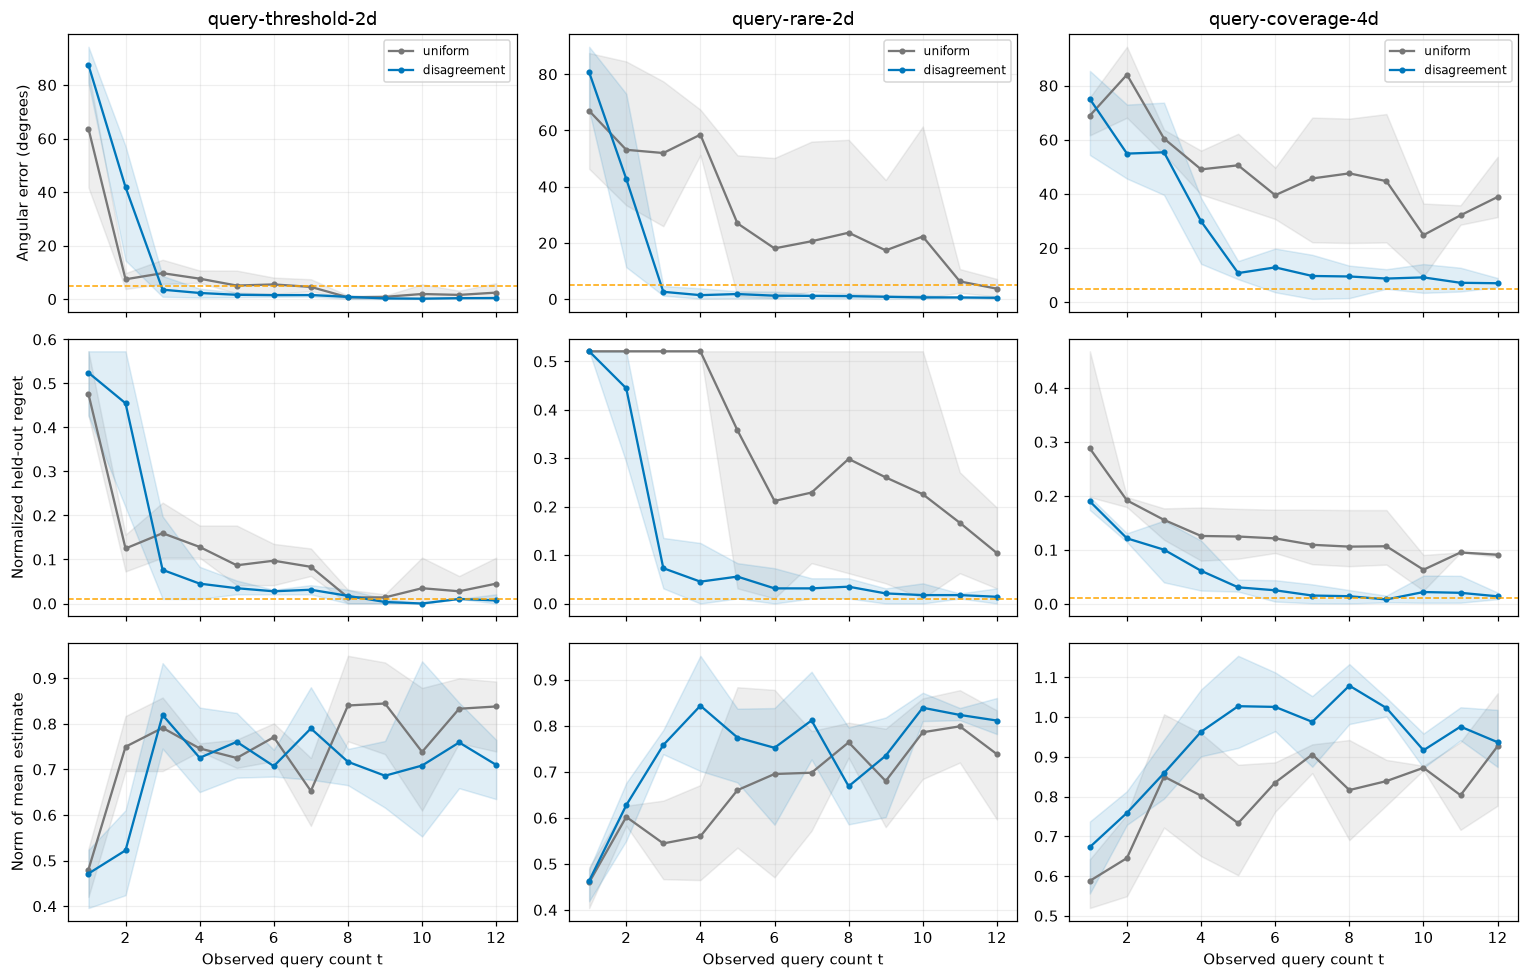

In [5]:
names = list(designs)
colors = {"uniform": "#777777", "disagreement": "#0077bb"}
fig, axes = plt.subplots(3, 3, figsize=(14,9), sharex=True)
for col, name in enumerate(names):
    for policy in ("uniform", "disagreement"):
        selected = [runs[(name, seed, policy)] for seed in SEEDS]
        histories = [
            np.array([r.evaluation["angular_error_history_degrees"] for r in selected]),
            np.array([r.evaluation["normalized_regret_history"] for r in selected]),
            np.array([np.linalg.norm(r.parameter_history, axis=1) for r in selected]),
        ]
        for row, values in enumerate(histories):
            ax = axes[row,col]
            ax.plot(range(1,T+1), values.mean(axis=0), "-o", ms=3, color=colors[policy], label=policy)
            ax.fill_between(range(1,T+1), values.min(axis=0), values.max(axis=0),
                            color=colors[policy], alpha=.12)
    axes[0,col].set_title(name)
    axes[0,col].axhline(5, color="orange", ls="--", lw=1)
    axes[1,col].axhline(.01, color="orange", ls="--", lw=1)
    axes[2,col].set_xlabel("Observed query count t")
    axes[0,col].legend(fontsize=8)
for row, label in enumerate(["Angular error (degrees)", "Normalized held-out regret", "Norm of mean estimate"]):
    axes[row,0].set_ylabel(label)
plt.tight_layout(); plt.show()

## 5. What was selected at each time step? (Seed 0)

Dots show every selected ratio and, for 4D, its coordinate pair. The red mark indicates that parameter noise changed this query's observed decision compared with the clean expert. Horizontal dashed lines show hidden true thresholds **only in this evaluator plot**, never to the algorithm. The table includes seed-to-seed candidate coverage.

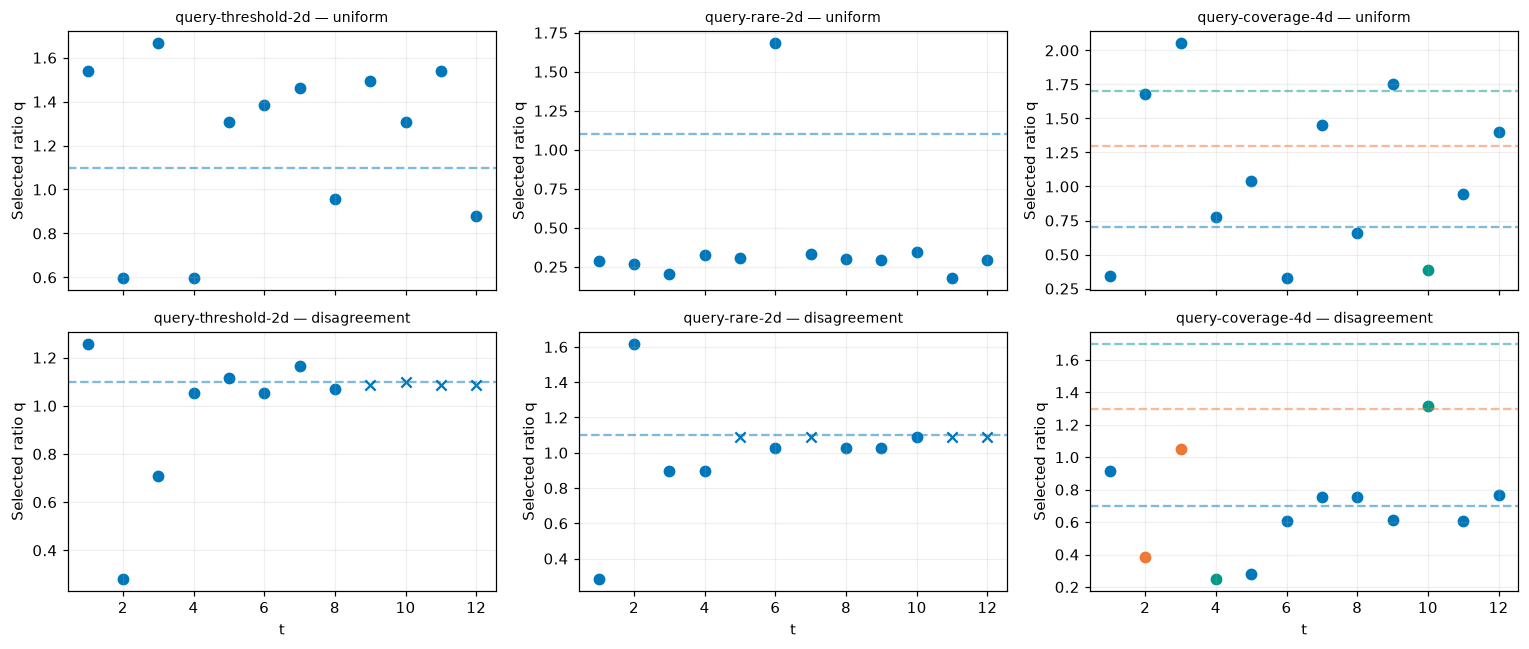

,scenario,seed,policy,group 0,group 1,group 2,group 3
0,query-threshold-2d,0,uniform,12.0,-,-,-
1,query-threshold-2d,0,disagreement,12.0,-,-,-
2,query-rare-2d,0,uniform,11.0,1.0,-,-
3,query-rare-2d,0,disagreement,1.0,11.0,-,-
4,query-coverage-4d,0,uniform,-,11.0,0.0,1.0
5,query-coverage-4d,0,disagreement,-,8.0,2.0,2.0
6,query-threshold-2d,1,uniform,12.0,-,-,-
7,query-threshold-2d,1,disagreement,12.0,-,-,-
8,query-rare-2d,1,uniform,11.0,1.0,-,-
9,query-rare-2d,1,disagreement,1.0,11.0,-,-


In [6]:
fig, axes = plt.subplots(2,3,figsize=(14,6),sharex=True)
for col,name in enumerate(names):
    for row,policy in enumerate(("uniform","disagreement")):
        run = runs[(name,0,policy)]
        ax = axes[row,col]
        for record in run.records:
            s = record.query
            if len(s) == 2:
                ratio, group = s[0]/s[1], 1
            else:
                group = int(np.flatnonzero(s[1:])[0]+1)
                ratio = s[0]/s[group]
            clean = np.argmin(run.true_theta*s)
            flipped = int(np.argmax(record.observed_decision)) != clean
            ax.scatter(record.step, ratio, color=["#0077bb","#ee7733","#009988"][group-1],
                       marker="x" if flipped else "o", s=45)
        thresholds = run.true_theta[1:] / run.true_theta[0]
        for group, threshold in enumerate(thresholds):
            ax.axhline(threshold, ls="--", color=["#0077bb","#ee7733","#009988"][group], alpha=.5)
        ax.set_title(f"{name} — {policy}", fontsize=9)
        ax.set_ylabel("Selected ratio q")
        axes[1,col].set_xlabel("t")
plt.tight_layout(); plt.show()
coverage = []
for (name,seed,policy), run in runs.items():
    groups = run.metadata["selected_candidate_groups"]
    counts = {f"group {g}": groups.count(g) for g in sorted(set(designs[name].candidate_groups))}
    coverage.append({"scenario":name,"seed":seed,"policy":policy,**counts})
display(pd.DataFrame(coverage).fillna("-"))

## 6. Loss over theta at EVERY time step (both 2D scenarios, active policy, seed 0)

Each panel uses only the observations available by that time. Background colors show the cumulative inverse loss L_t(theta), evaluated directly over the full box. Orange dots are the current sampling ensemble, the black cross is its mean estimate, and the red star is theta* (evaluation only). One color scale is shared across all time steps within each scenario.

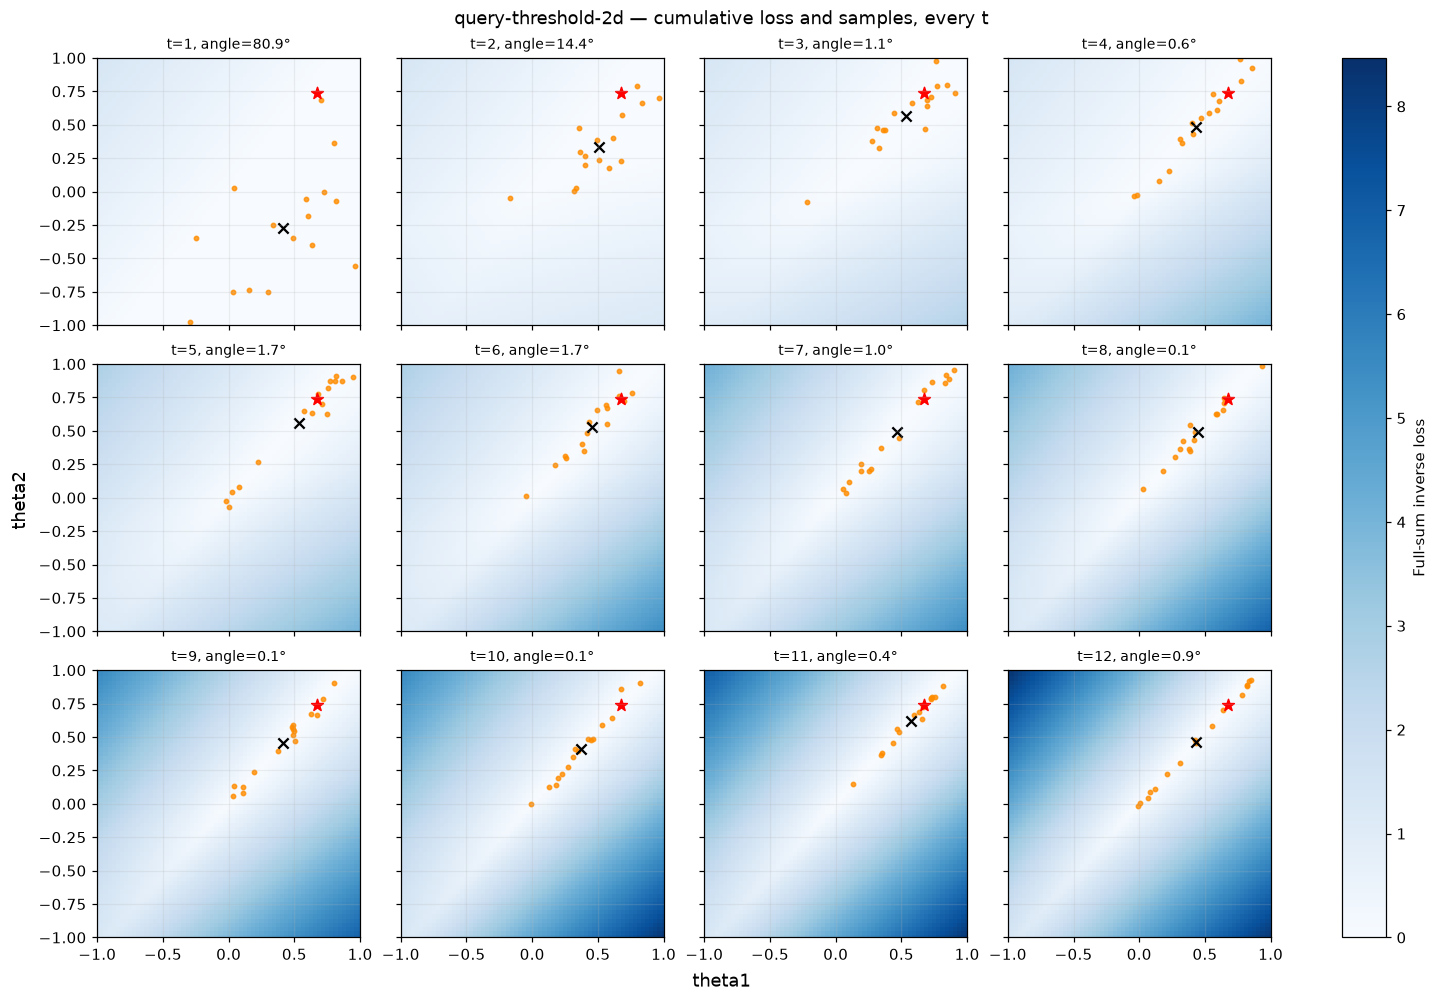

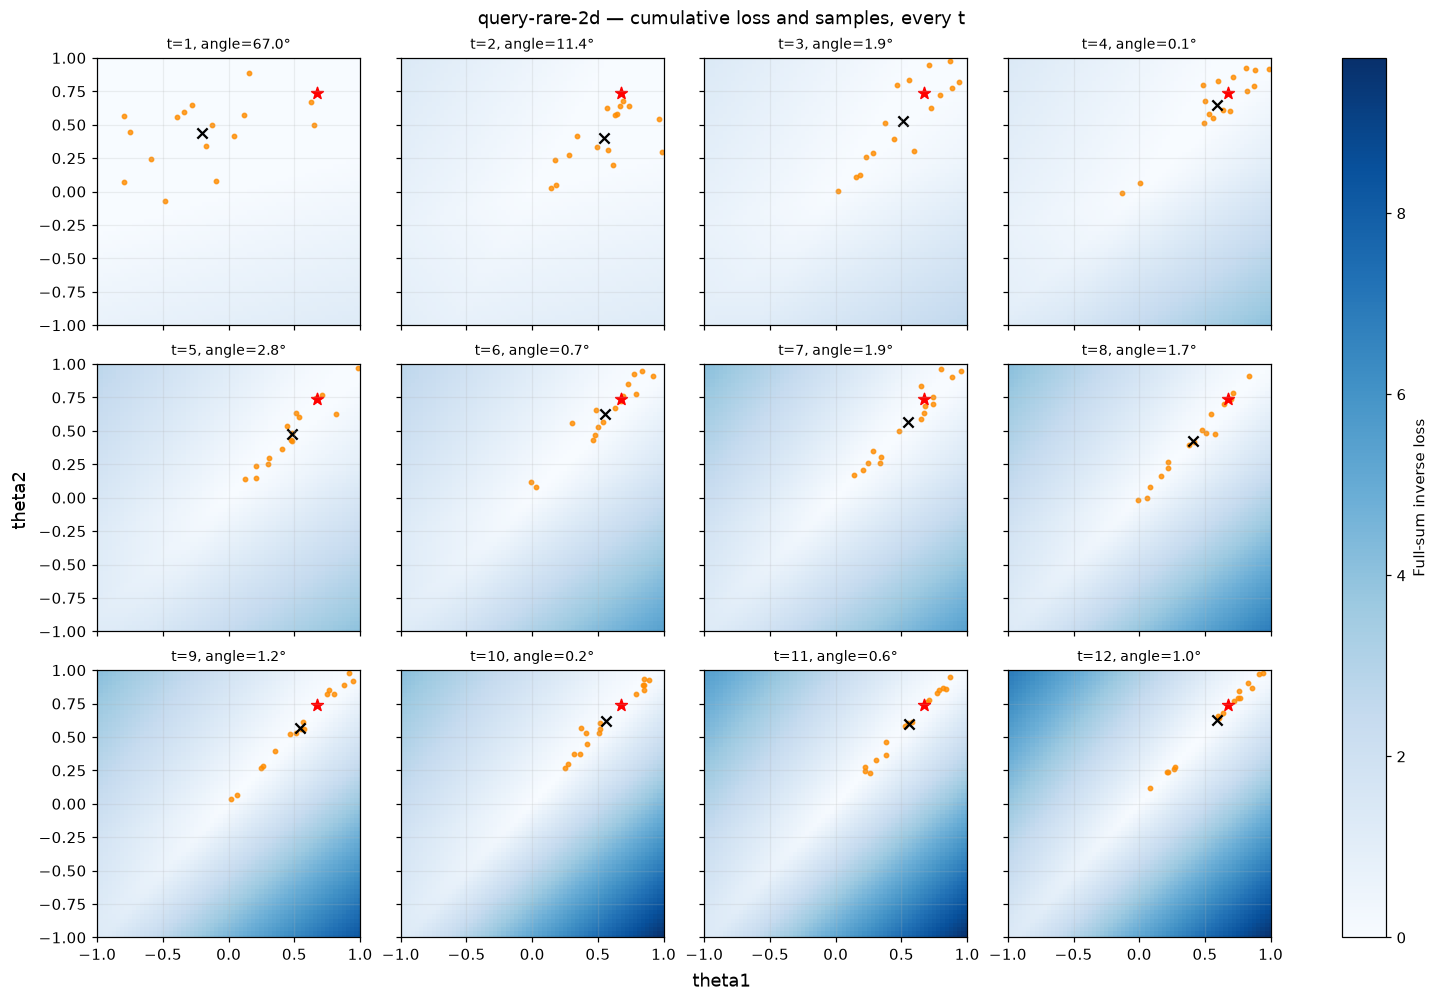

In [7]:
axis = np.linspace(-1,1,65)
xx, yy = np.meshgrid(axis,axis)
grid = np.c_[xx.ravel(), yy.ravel()]
for name in names[:2]:
    run = runs[(name,0,"disagreement")]
    losses, cumulative = [], np.zeros(len(grid))
    for record in run.records:
        costs = grid*record.query
        cumulative += (costs*record.observed_decision).sum(axis=1) - costs.min(axis=1)
        losses.append(cumulative.copy())
    fig, axes = plt.subplots(3,4,figsize=(13,9),sharex=True,sharey=True,layout="constrained")
    for ax,record,loss in zip(axes.flat,run.records,losses):
        mesh = ax.pcolormesh(xx,yy,loss.reshape(xx.shape),shading="auto",cmap="Blues",
                             vmin=0,vmax=max(losses[-1]))
        samples = np.array(record.update_diagnostics["theta_samples"])
        ax.scatter(samples[:,0],samples[:,1],s=8,c="darkorange",alpha=.8)
        ax.scatter(*record.theta_hat_after,s=45,c="black",marker="x")
        ax.scatter(*run.true_theta,s=65,c="red",marker="*")
        ax.set_title(f"t={record.step}, angle={run.evaluation['angular_error_history_degrees'][record.step-1]:.1f}°",
                     fontsize=9)
        ax.set(xlim=(-1,1),ylim=(-1,1))
    fig.supxlabel("theta1"); fig.supylabel("theta2")
    fig.suptitle(name+" — cumulative loss and samples, every t")
    fig.colorbar(mesh,ax=axes.ravel().tolist(),label="Full-sum inverse loss")
    plt.show()

## 7. Readout and limits

In this three-seed run, final mean angular error (uniform -> disagreement) is **2.43 -> 0.40 degrees** for threshold localization, **3.68 -> 0.44 degrees** for rare informative queries, and **38.88 -> 7.02 degrees** for coordinate coverage. The rare-query active runs stay below 5 degrees from t=3 in all three seeds. The 4D active runs improve substantially but none remains below 5 degrees through T. One threshold seed still has slightly worse final angular error under active queries.

For the two-action 2D cases, one mistaken held-out decision contributes 1/96 = 0.01042 normalized mean regret, so the 0.01 threshold effectively requires zero mistakes on these 96 tests. It does NOT mean exact theta recovery. Wall-clock times are illustrative: validation/tests were running on the same machine, so use query counts rather than these timings to claim sample efficiency.

The comparison below counts paired wins and threshold attainment without discarding unfavorable seeds. The retained legacy outputs remain untouched: they represent the original algorithm and must not be relabeled as corrected results.

This notebook establishes numerical sanity on specified small reference targets and demonstrates the full query-selection workflow. It does not establish reliable recovery for all parameter-noise distributions or superiority in high dimensions. More seeds, larger horizons and posterior/likelihood choices remain separate research decisions.

In [8]:
paired = results.pivot(index=["scenario","seed"], columns="policy", values=["final angle","final regret"])
readout = []
for name in names:
    subset = paired.loc[name]
    row = {"scenario":name}
    for metric in ("final angle","final regret"):
        difference = subset[metric]["disagreement"] - subset[metric]["uniform"]
        row[f"active better: {metric}"] = int((difference < -1e-12).sum())
        row[f"tied: {metric}"] = int((np.abs(difference) <= 1e-12).sum())
        row[f"active worse: {metric}"] = int((difference > 1e-12).sum())
    readout.append(row)
display(pd.DataFrame(readout))
hits = results.groupby(["scenario","policy"])[
    ["first angle<=5","sustained angle<=5","first regret<=.01","sustained regret<=.01","first joint","sustained joint"]].count()
display(hits.rename(columns=lambda c: c+" (count / 3)"))
print("Completed: 18/18 small noisy runs, all 12 steps; validation gates passed.")
print("No claim that zero test regret means exact theta recovery.")
print("The point estimator and sampler are identical between policies; runtime includes t=0 sampling.")
print("Executed notebook:", ROOT / "notebooks" / "14_corrected_diffusion_validation.ipynb")

,scenario,active better: final angle,tied: final angle,active worse: final angle,active better: final regret,tied: final regret,active worse: final regret
0,query-threshold-2d,2,0,1,2,1,0
1,query-rare-2d,3,0,0,3,0,0
2,query-coverage-4d,3,0,0,3,0,0


first angle<=5 (count / 3)  \
scenario           policy                                     
query-coverage-4d  disagreement                           2   
                   uniform                                0   
query-rare-2d      disagreement                           3   
                   uniform                                2   
query-threshold-2d disagreement                           3   
                   uniform                                3   

                                 sustained angle<=5 (count / 3)  \
scenario           policy                                         
query-coverage-4d  disagreement                               0   
                   uniform                                    0   
query-rare-2d      disagreement                               3   
                   uniform                                    2   
query-threshold-2d disagreement                               3   
                   uniform                                    2   

                                 first regret<=.01 (count / 3)  \
scenario           policy                                        
query-coverage-4d  disagreement                              2   
                   uniform                                   0   
query-rare-2d      disagreement                              3   
                   uniform                                   0   
query-threshold-2d disagreement                              3   
                   uniform                                   2   

                                 sustained regret<=.01 (count / 3)  \
scenario           policy                                            
query-coverage-4d  disagreement                                  1   
                   uniform                                       0   
query-rare-2d      disagreement                                  1   
                   uniform                                       0   
query-threshold-2d disagreement                                  2   
                   uniform                                       0   

                                 first joint (count / 3)  \
scenario           policy                                  
query-coverage-4d  disagreement                        2   
                   uniform                             0   
query-rare-2d      disagreement                        3   
                   uniform                             0   
query-threshold-2d disagreement                        3   
                   uniform                             2   

                                 sustained joint (count / 3)  
scenario           policy                                     
query-coverage-4d  disagreement                            0  
                   uniform                                 0  
query-rare-2d      disagreement                            1  
                   uniform                                 0  
query-threshold-2d disagreement                            2  
                   uniform                                 0

Completed: 18/18 small noisy runs, all 12 steps; validation gates passed.
No claim that zero test regret means exact theta recovery.
The point estimator and sampler are identical between policies; runtime includes t=0 sampling.
Executed notebook: C:\Users\payam\Desktop\Inverse Optimization\notebooks\14_corrected_diffusion_validation.ipynb
